Defining the percentage of oil that goes below the surface layer in the Haro Boundary region, for use in Atlantis dilbit spills. Based on original notebook from Susan Allen as part of the MIDOSS project.

In [1]:
import copy
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

%matplotlib inline

In [2]:
plt.rcParams.update({'font.size': 13})

In [3]:
thefile = '/data/sallen/MIDOSS/aggregated_spills_files/fiftieth_55_oils.nc'
oil = xr.open_dataset(thefile)
whichspills = "All Oil Spills"
smalloils = 113 + 54

In [4]:
mesh = xr.open_dataset('/home/sallen/MEOPAR/grid/mesh_mask201702.nc')
tmask = 1- mesh.tmask[0, 0]
divarea = 1/(mesh.e1t[0, 1:-1, 1:-1] * mesh.e2t[0, 1:-1, 1:-1])
alength = 1/np.maximum(mesh.e1t[0, 1:-1:, 1:-1], mesh.e2t[0, 1:-1, 1:-1])
mesh.close()

In [5]:
# Refined for Haro Boundary Region
imin = 200
jmin, jmax = 150, 350
#imax = imin + (jmax - jmin)*2/500*440
imax = 500
aspect = 500/440

In [6]:
oil.data_vars

Data variables:
    beaching_time    (c, grid_y, grid_x) float64 ...
    beachpresence    (grid_y, grid_x) float64 ...
    beaching_oil     (c, grid_y, grid_x) float64 ...
    oiling_time      (c, grid_y, grid_x) float64 ...
    oilpresence      (grid_y, grid_x) float64 ...
    surface_oil      (c, grid_y, grid_x) float64 ...
    deeppresence     (grid_y, grid_x) float64 ...
    deep_oil         (c, grid_y, grid_x) float64 ...
    deep_location    (c, grid_y, grid_x) float64 ...
    files_aggregate  (nf) object ...
    nofiles          int64 ...

In [7]:
def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=-1):
    if n == -1:
        n = cmap.N
    new_cmap = colors.LinearSegmentedColormap.from_list(
         'trunc({name},{a:.2f},{b:.2f})'.format(name=cmap.name, a=minval, b=maxval),
         cmap(np.linspace(minval, maxval, n)))
    return new_cmap

In [8]:
minColor = 0.1
maxColor = 0.85
need = 4   # need four values at a point to calculate quartiles

### Surface oil

In [9]:
ma_oil_pres = np.ma.masked_array(oil.oilpresence, oil.oilpresence == 0)

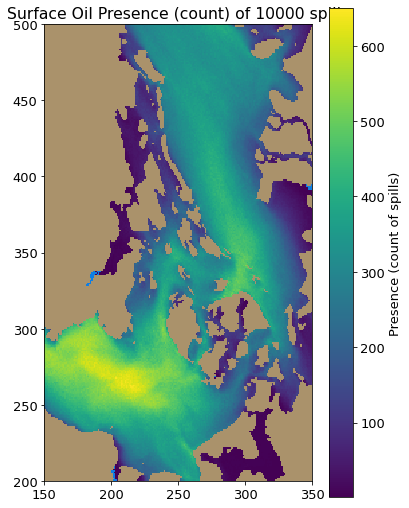

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(6, 9))

ax.pcolormesh(tmask[1:, 1:], cmap='terrain', vmin=-0.2, vmax=1.6)
ax.set_ylim(imin, imax)
ax.set_xlim(jmin, jmax)
ax.set_aspect(aspect)


C = ax.pcolormesh(ma_oil_pres, zorder=2,)# cmap='gist_ncar')
cb = fig.colorbar(C, ax=ax);    
cb.set_label('Presence (count of spills)')
ax.set_title(f'Surface Oil Presence (count) of {oil.nofiles.values+smalloils} spills');   

Surface oil volume

In [11]:
absol = 0.5
perol = 0.25
eps = 1e-7
mcsize = 49

bt_absol = absol
bt_perol = perol

In [12]:
ma_surface_oil = np.ma.masked_array(oil.surface_oil[0]/(oil.oilpresence + eps), 
                                    oil.oilpresence == 0)

surfoil_25 = np.quantile(oil.surface_oil/(oil.oilpresence + eps), 0.25, axis=0)
surfoil_75 = np.quantile(oil.surface_oil/(oil.oilpresence + eps), 0.75, axis=0)

surfoiled = np.ma.masked_array(oil.surface_oil[0]/(oil.oilpresence + eps), 
                               (oil.oilpresence < need) | (
    (np.exp(surfoil_75) - np.exp(surfoil_25) > np.exp(ma_surface_oil)) )) 

ma_surfoil_del = np.ma.masked_array(np.exp(surfoil_75) - 
                                    np.exp(surfoil_25), oil.oilpresence < need)

print (ma_surface_oil.max(), surfoil_75.max())

7.129695074040375 14.055608038963308


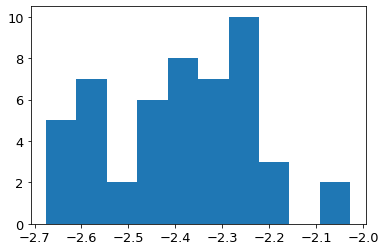

In [13]:
plt.hist(oil.surface_oil[:, 400, 300]/(oil.oilpresence[400, 300] + eps));

### Deep oil

In [14]:
ma_deep_pres = np.ma.masked_array(oil.deeppresence, oil.deeppresence == 0)

In [15]:
absol = 5
perol = 0.25

wd_absol = absol
wd_perol = perol

In [16]:
	
ma_deep_location = np.ma.masked_array(oil.deep_location[0]/(oil.deeppresence + eps), 
                                      oil.deeppresence == 0)
print (oil.deep_location.shape)
location_25 = np.quantile(oil.deep_location/(oil.deeppresence + eps), 0.25, axis=0)
location_75 = np.quantile(oil.deep_location/(oil.deeppresence + eps), 0.75, axis=0)
print (location_25.shape)

location = np.ma.masked_array(oil.deep_location[0]/(oil.deeppresence + eps), 
                              (oil.deeppresence < need) | (
    (location_75 - location_25 > absol) 
    & (location_75 - location_25 > perol*ma_deep_location))) 

ma_location_del = np.ma.masked_array(location_75 - location_25, oil.deeppresence < need)

print (ma_deep_location.max())

(50, 896, 396)
(896, 396)
279.9262886394291


55.88931975981047 <xarray.DataArray 'deeppresence' ()>
array(378.)
Coordinates:
    grid_x   int64 300
    grid_y   int64 350
    grid_z   int16 ...


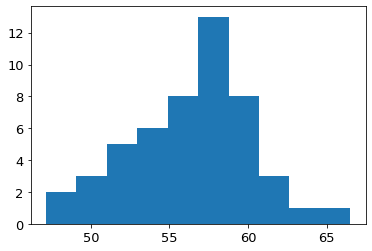

In [17]:
plt.hist(oil.deep_location[:, 350, 300]/oil.deeppresence[350, 300]);
print (ma_deep_location[350, 300], oil.deeppresence[350, 300])

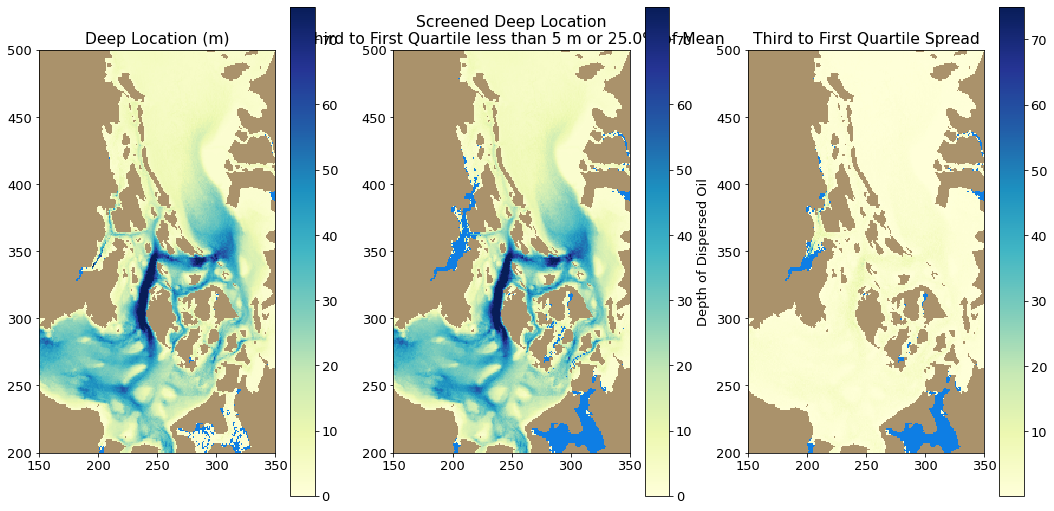

In [18]:
fig, axs = plt.subplots(1, 3, figsize=(18, 9))

for ax in axs:
    ax.pcolormesh(tmask[1:, 1:], cmap='terrain', vmin=-0.2, vmax=1.6)
    ax.set_ylim(imin, imax)
    ax.set_xlim(jmin, jmax)
    ax.set_aspect(aspect)

C = axs[0].pcolormesh(
     ma_deep_location,
    zorder=2, vmin=0, vmax=75, cmap=cm.YlGnBu
)
cb = fig.colorbar(C, ax=axs[0]);    
axs[0].set_title('Deep Location (m)');    

C = axs[1].pcolormesh(
     location,
    zorder=2, vmin=0, vmax=75, cmap=cm.YlGnBu
)
cb = fig.colorbar(C, ax=axs[1]);
cb.set_label('Depth of Dispersed Oil')
axs[1].set_title(
    f'Screened Deep Location\n Third to First Quartile less than {wd_absol} m or {wd_perol*100}% of Mean')

C = axs[2].pcolormesh(ma_location_del, 
    zorder=2, vmax=75, cmap=cm.YlGnBu
)
cb = fig.colorbar(C, ax=axs[2]);
axs[2].set_title('Third to First Quartile Spread');

Deep oil volume

In [19]:
ma_deep_oil = np.ma.masked_array(oil.deep_oil[0]/(oil.deeppresence + eps), 
                                 oil.deeppresence == 0)

deepoil_25 = np.quantile(oil.deep_oil/(oil.deeppresence + eps), 0.25, axis=0)
deepoil_75 = np.quantile(oil.deep_oil/(oil.deeppresence + eps), 0.75, axis=0)

deepoiled = np.ma.masked_array(oil.deep_oil[0]/(oil.deeppresence + eps), 
                               (oil.deeppresence < need) | (
    (np.exp(deepoil_75) - np.exp(deepoil_25) > np.exp(ma_deep_oil)) )) 

ma_deepoil_ste = np.ma.masked_array(np.exp(deepoil_75) 
                                    - np.exp(deepoil_25), oil.deeppresence < need)

### Comparison

In [21]:
all_oil_presence = oil.deeppresence + oil.oilpresence

In [22]:
all_oil_presence.dims

('grid_y', 'grid_x')

In [23]:
percent_deeppresence = oil.deeppresence / all_oil_presence

In [24]:
percent_surface_presence = oil.oilpresence / all_oil_presence

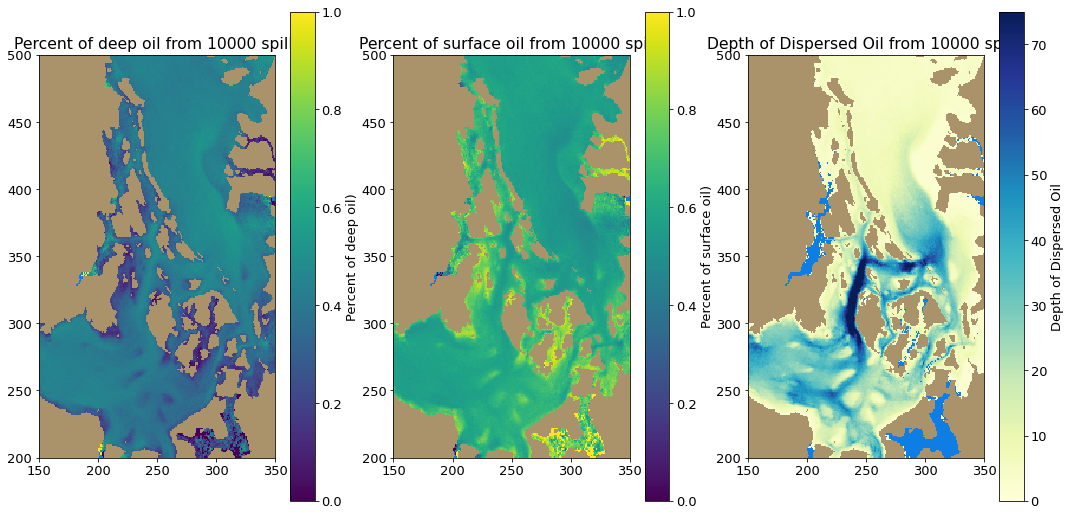

In [25]:
fig, axs = plt.subplots(1, 3, figsize=(18, 9))

for ax in axs:
    ax.pcolormesh(tmask[1:, 1:], cmap='terrain', vmin=-0.2, vmax=1.6)
    ax.set_ylim(imin, imax)
    ax.set_xlim(jmin, jmax)
    ax.set_aspect(aspect)

C = axs[0].pcolormesh(percent_deeppresence, zorder=2)# cmap='gist_ncar')
cb = fig.colorbar(C, ax=axs[0]);    
cb.set_label('Percent of deep oil)')
axs[0].set_title(f'Percent of deep oil from {oil.nofiles.values+smalloils} spills');   

C = axs[1].pcolormesh(percent_surface_presence, zorder=2)# cmap='gist_ncar')
cb = fig.colorbar(C, ax=axs[1]);    
cb.set_label('Percent of surface oil)')
axs[1].set_title(f'Percent of surface oil from {oil.nofiles.values+smalloils} spills');  

C = axs[2].pcolormesh(
     location,
    zorder=2, vmin=0, vmax=75, cmap=cm.YlGnBu
)
cb = fig.colorbar(C, ax=axs[2]);
cb.set_label('Depth of Dispersed Oil')
axs[2].set_title(
    f'Depth of Dispersed Oil from {oil.nofiles.values+smalloils} spills');

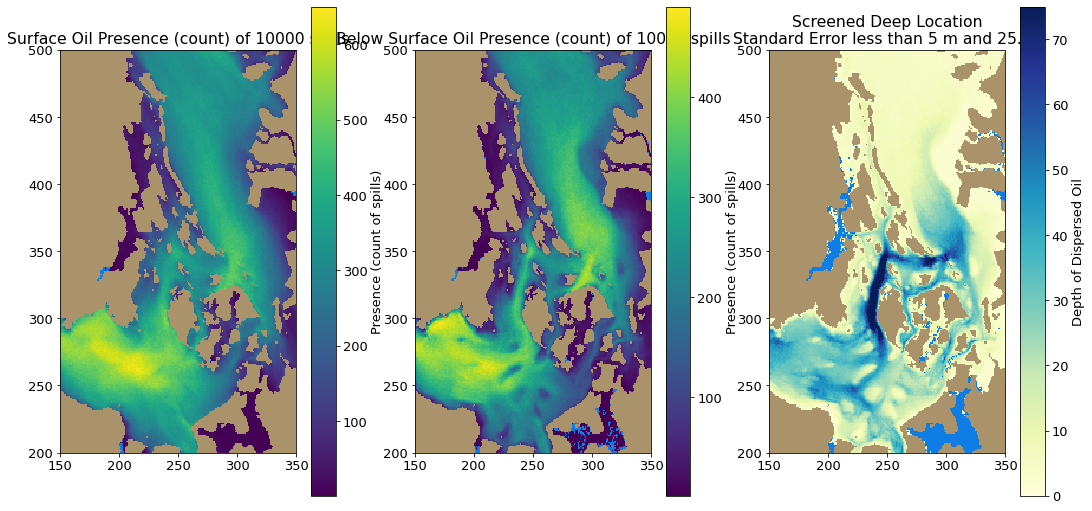

In [26]:
fig, axs = plt.subplots(1, 3, figsize=(18, 9))

for ax in axs:
    ax.pcolormesh(tmask[1:, 1:], cmap='terrain', vmin=-0.2, vmax=1.6)
    ax.set_ylim(imin, imax)
    ax.set_xlim(jmin, jmax)
    ax.set_aspect(aspect)
        
C = axs[0].pcolormesh(ma_oil_pres, zorder=2)
cb = fig.colorbar(C, ax=axs[0]);    
cb.set_label('Presence (count of spills)')
axs[0].set_title(
    f'Surface Oil Presence (count) of {oil.nofiles.values+smalloils} spills');  

C = axs[1].pcolormesh(ma_deep_pres, zorder=2)
cb = fig.colorbar(C, ax=axs[1]);    
cb.set_label('Presence (count of spills)')
axs[1].set_title(
    f'Below Surface Oil Presence (count) of {oil.nofiles.values+smalloils} spills');   

C = axs[2].pcolormesh(
     location,
    zorder=2, vmin=0, vmax=75, cmap=cm.YlGnBu
)
cb = fig.colorbar(C, ax=axs[2]);
cb.set_label('Depth of Dispersed Oil')
axs[2].set_title(
    f'Screened Deep Location\n Standard Error less than {wd_absol} m and {wd_perol*100}%');

In [27]:
spill_depths = np.ma.masked_array(oil.deep_location[0,200:500,150:350]/(oil.deeppresence[200:500,150:350] + eps))

In [28]:
depth_bins = [0, 25, 50, 100]

In [29]:
counts, edges = np.histogram(spill_depths, bins=depth_bins)

In [30]:
percentages = counts / counts.sum() * 100

In [31]:
for i in range(len(counts)):
    print(f"{edges[i]}–{edges[i+1]} m: {percentages[i]:.1f}%")

0–25 m: 83.7%
25–50 m: 14.3%
50–100 m: 1.9%


Text(0, 0.5, '% oil')

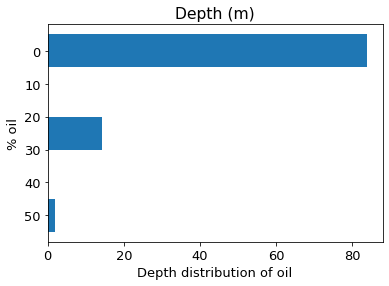

In [45]:
plt.barh(edges[0:3],percentages, height=10, align='center')
plt.gca().invert_yaxis() 
plt.title('Depth (m)')
plt.xlabel('Depth distribution of oil')
plt.ylabel('% oil')
